In [ ]:
#Load the data

In [40]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [41]:
df = pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# Eksplorasi awal

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [43]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [44]:
df.shape

(891, 12)

In [45]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [47]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
Cabin,687,0.771044
Age,177,0.198653
Embarked,2,0.002245
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


In [ ]:
# Menjelajahi & Memvisualisasikan Data Untuk Mendapatkan Wawasan

In [48]:
df = df.copy()

In [49]:
# Isi nilai age yang hilang dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())
# Isi nilai Embarked yang hilang dengan mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Terapkan log1p ke age
df['log_age'] = np.log1p(df['Age'])
# Terapkan log1p ke  Fare
df['log_fare'] = np.log1p(df['Fare'])

In [50]:
sns.set_style("whitegrid")

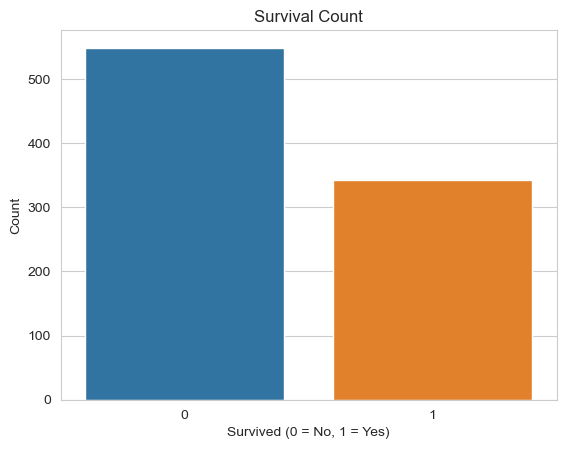

In [51]:
sns.countplot(x='Survived', data=df)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Survival Count')
plt.show()

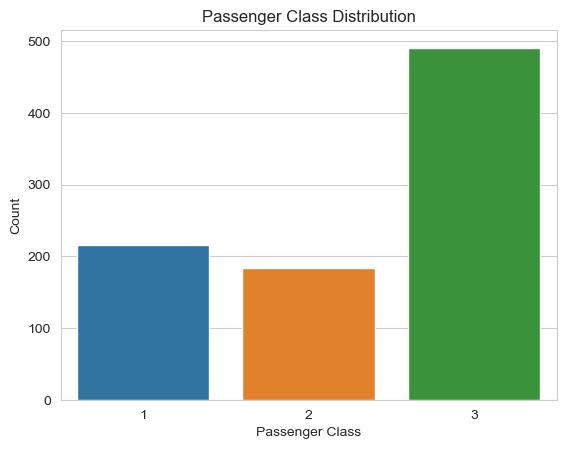

In [52]:
sns.countplot(x='Pclass', data=df)
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.title('Passenger Class Distribution')
plt.show()

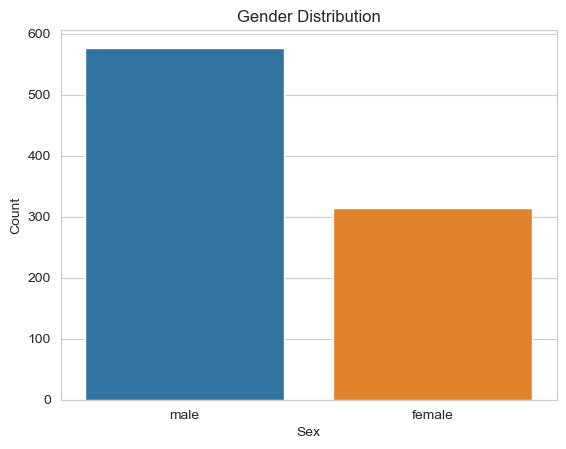

In [53]:
sns.countplot(x='Sex', data=df)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

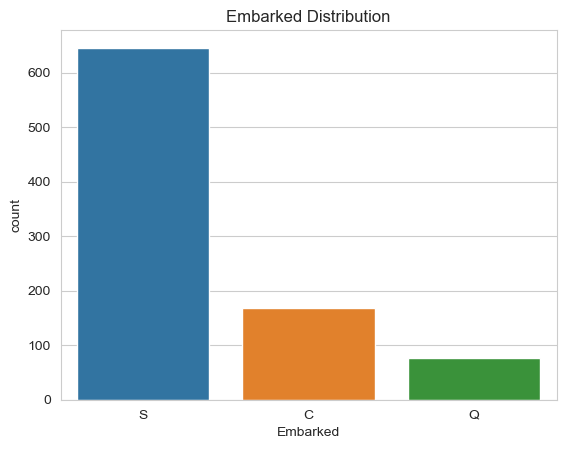

In [54]:
sns.countplot(x='Embarked', data=df)
plt.title('Embarked Distribution')
plt.show()

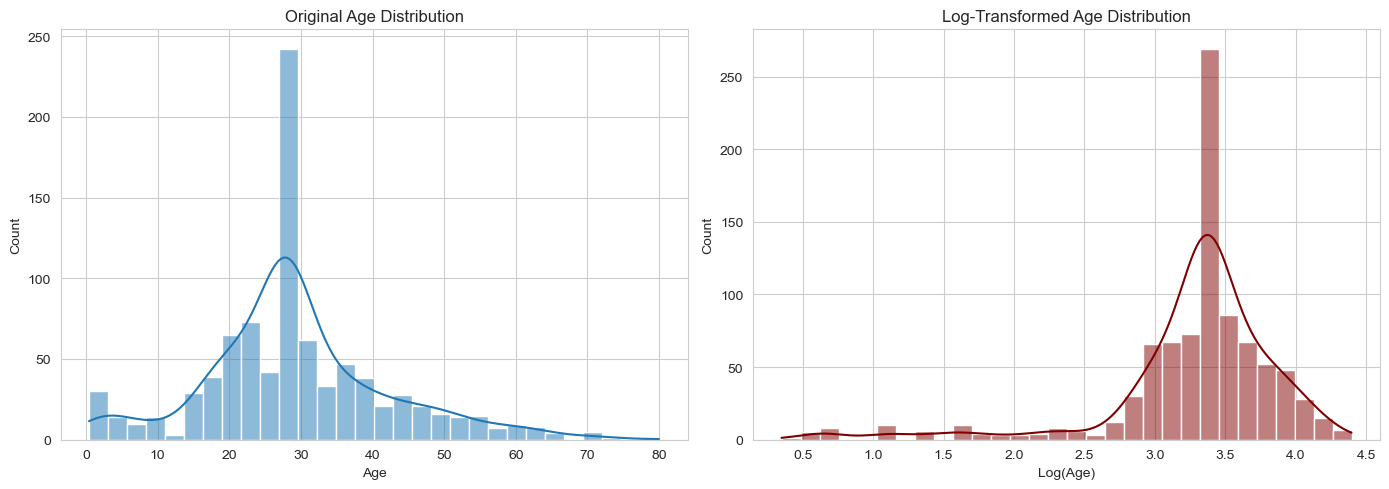

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi age Asli
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Original Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Distribusi age yang Ditransformasikan Secara Logaritma
sns.histplot(df['log_age'], bins=30, kde=True, ax=axes[1], color='maroon')
axes[1].set_title('Log-Transformed Age Distribution')
axes[1].set_xlabel('Log(Age)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

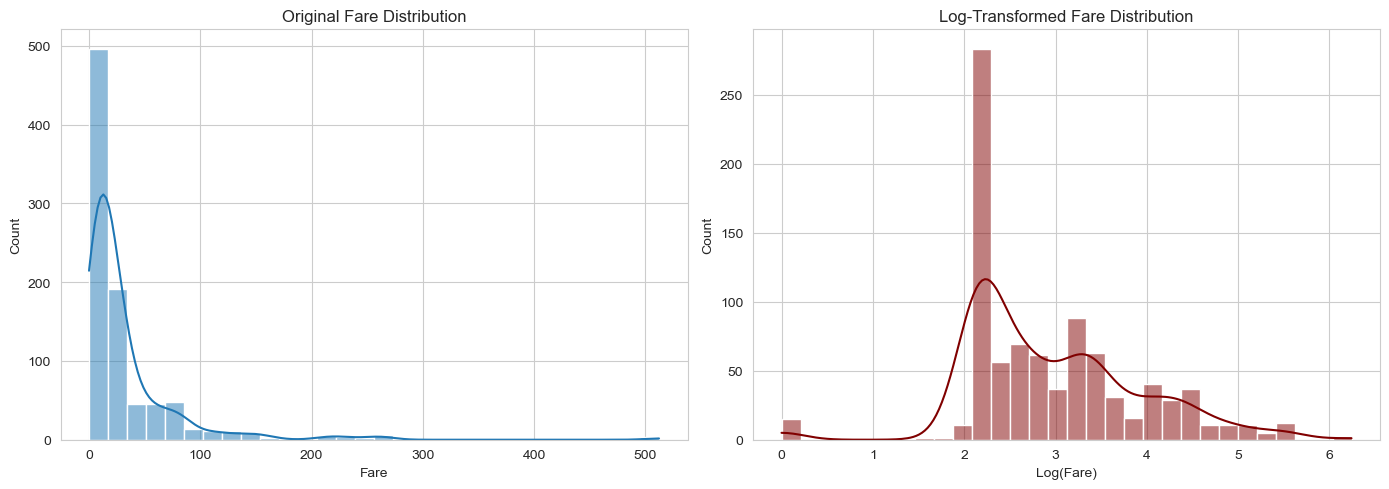

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi fare Asli
sns.histplot(df['Fare'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Original Fare Distribution')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Count')

# Distribusi fare yang Ditransformasikan Secara Logaritma
sns.histplot(df['log_fare'], bins=30, kde=True, ax=axes[1], color="maroon")
axes[1].set_title('Log-Transformed Fare Distribution')
axes[1].set_xlabel('Log(Fare)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [57]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,log_age,log_fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.135494,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3.663562,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3.295837,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.583519,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3.583519,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,3.332205,2.639057
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,2.995732,3.433987
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S,3.367296,3.196630
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,3.295837,3.433987


In [93]:
# Menjelajahi hubungan antara fitur & target

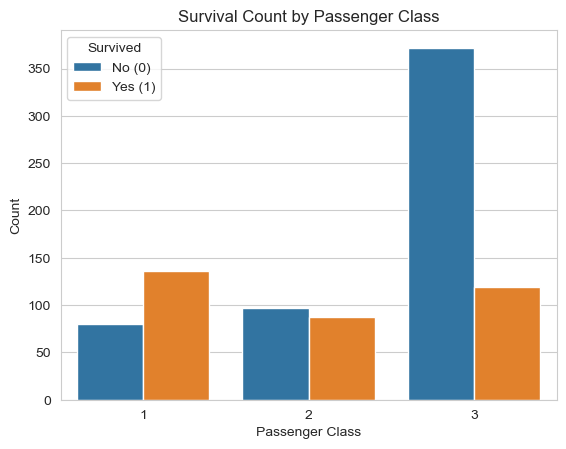

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already defined elsewhere

# Convert numeric columns to category type - this is where the error occurs
# Instead of using astype('category'), we need to explicitly convert to string first
df['Pclass'] = df['Pclass'].astype(str).astype('category')
df['Survived'] = df['Survived'].astype(str).astype('category')

# Now create the plot
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.title('Survival Count by Passenger Class')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

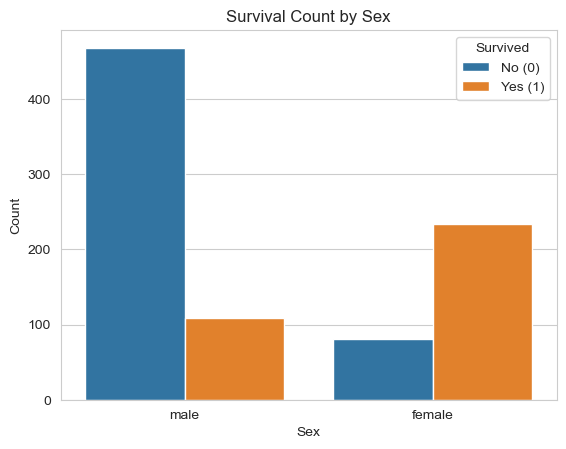

In [61]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Survival Count by Sex')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

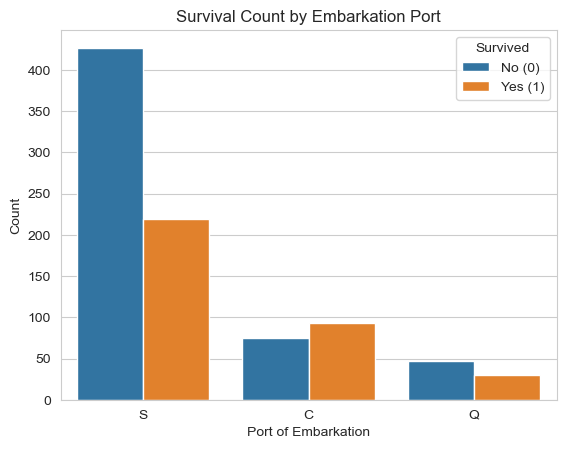

In [63]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.xlabel('Port of Embarkation')
plt.ylabel('Count')
plt.title('Survival Count by Embarkation Port')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

In [94]:
# Mempersiapkan Data Untuk Algoritma Ml

In [64]:
# Dropping Irrelevant Columns
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.drop(['Age', 'Fare'], axis=1, inplace=True)
df.drop('Cabin', axis=1, inplace=True)

In [66]:
# Menghilangkan Kolom yang Tidak Relevan
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [67]:
# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [68]:
# Split Features & Target
titanic_features  = df.drop('Survived', axis=1)
titanic_target  = df['Survived']

In [69]:
# Spliting into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(titanic_features, titanic_target, test_size=0.2, random_state=42)

In [70]:
# Scaling Numerical Features
scaler = StandardScaler()
numerical_cols = ['Pclass','log_age', 'log_fare', 'SibSp', 'Parch', 'FamilySize']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [71]:
# Verifying shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 9)
X_test shape: (179, 9)
y_train shape: (712,)
y_test shape: (179,)


In [ ]:
# Memilih Model & Melatihnya

In [72]:
# sgd_clf = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
# sgd_clf.fit(X_train, y_train)

In [73]:
# Tune SGDClassifier
param_grid = {'alpha': [0.0001, 0.001, 0.01], 'max_iter': [1000, 2000]}
sgd_clf = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
grid_search = GridSearchCV(sgd_clf, param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)
sgd_clf = grid_search.best_estimator_
print("Best SGD params:", grid_search.best_params_)

D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:778: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 767, in _score
    scores = scorer(estimator, X_test, y_test)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_scorer.py", line 234, in __call__
    return self._score(
           ^^^^^^^^^^^^
  File "D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_scorer.py", line 282, in _score
    return self._sign * self._score_func(y_true, y_pred, **self._kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py", line 1146, in f1_score
    return fbeta_score(
           ^^^^^^^^^^^^
  File "D:\APLIKAS

Best SGD params: {'alpha': 0.0001, 'max_iter': 1000}


D:\APLIKASI\Anaconda\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


In [75]:
# Train and evaluate SGD
y_train_pred_sgd = cross_val_predict(sgd_clf, X_train, y_train, cv=3)
print("SGD F1-Score:", f1_score(y_train, y_train_pred_sgd, pos_label='1'))

SGD F1-Score: 0.712041884816754


In [76]:
# Accuracy can lie to you — somtimes
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.7394958 , 0.79746835, 0.76793249])

In [77]:
# Confusion Matrix
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

In [78]:
cm = confusion_matrix(y_train, y_train_pred)
cm

array([[343, 101],
       [ 64, 204]], dtype=int64)

In [79]:
y_train_perfect_predictions = y_train # Pretend the model predicts perfectly
confusion_matrix(y_train, y_train_perfect_predictions)

array([[444,   0],
       [  0, 268]], dtype=int64)

In [ ]:
# Precision

In [80]:
display(Math(r'\text{Precision} = \frac{TP}{TP + FP}'))

<IPython.core.display.Math object>

In [82]:
# Ubah label string menjadi bilangan bulat sebelum menghitung skor presisi
from sklearn.preprocessing import LabelEncoder

# Opsi 1: Ubah label string menjadi bilangan bulat
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_train_pred_encoded = le.transform(y_train_pred)
precision_score(y_train_encoded, y_train_pred_encoded)

# Opsi 2: Tentukan parameter pos_label sebagai string
# precision_score(y_train, y_train_pred, pos_label='1')

0.6688524590163935

In [ ]:
# Recall

In [83]:
display(Math(r'\text{Recall} = \frac{TP}{TP + FN}'))

<IPython.core.display.Math object>

In [87]:
# Pastikan kedua array memiliki tipe yang sama (integers)
import numpy as np
y_train = np.array(y_train, dtype=int)
y_train_pred = np.array(y_train_pred, dtype=int)

# Kemudian hitung skor recall dengan pos_label eksplisit
from sklearn.metrics import recall_score
recall_score(y_train, y_train_pred, pos_label=1)

0.7611940298507462

In [ ]:
# F1 Score

In [88]:
f1_score(y_train, y_train_pred)

0.712041884816754

In [ ]:
# Logistic regression

In [89]:
log_reg = LogisticRegression(random_state=42,)
log_reg.fit(X_train, y_train)
y_train_pred_log = cross_val_predict(log_reg, X_train, y_train, cv=3)
print("Logistic Regression F1-Score:", f1_score(y_train, y_train_pred_log))

Logistic Regression F1-Score: 0.7201565557729942


In [90]:
# Tune LogisticRegression
param_grid = {'C': [0.01, 0.1, 1, 10]}
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
grid_search = GridSearchCV(log_reg, param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)
log_reg = grid_search.best_estimator_
print("Best Logistic params:", grid_search.best_params_)

Best Logistic params: {'C': 0.1}


In [92]:
# Evaluate LogisticRegression
# Ubah label string menjadi bilangan bulat sebelum menggunakannya
y_train = y_train.astype(int)  # Mengubah label string menjadi bilangan bulat
y_test = y_test.astype(int)    # Mengubah label string menjadi bilangan bulat

y_train_pred_log = cross_val_predict(log_reg, X_train, y_train, cv=3)
print("Logistic Regression Train F1-Score:", f1_score(y_train, y_train_pred_log))
y_test_pred_log = log_reg.predict(X_test)
print("Logistic Regression Test F1-Score:", f1_score(y_test, y_test_pred_log))

Logistic Regression Train F1-Score: 0.7447552447552448
Logistic Regression Test F1-Score: 0.7730061349693251


In [95]:
# RandomForest

In [96]:
# Tuned random forest
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5]}
rf_clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_clf, param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, y_train)
rf_clf = grid_search.best_estimator_
print("Best RF params:", grid_search.best_params_)

Best RF params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


In [97]:
# Cross-validate 
rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42)
y_train_pred_balanced = cross_val_predict(rf_balanced, X_train, y_train, cv=3)
print("Balanced Default RF Train F1-Score:", f1_score(y_train, y_train_pred_balanced))

Balanced Default RF Train F1-Score: 0.7117988394584139


In [98]:
# Cross-validate tuned model
y_train_pred_rf = cross_val_predict(rf_clf, X_train, y_train, cv=3)
print("Tuned RF Train F1-Score:", f1_score(y_train, y_train_pred_rf))

Tuned RF Train F1-Score: 0.7489878542510122


In [99]:
# Test set evaluation
y_test_pred_rf = rf_clf.predict(X_test)
print("Tuned RF Test F1-Score:", f1_score(y_test, y_test_pred_rf))
print("Test Precision:", precision_score(y_test, y_test_pred_rf))
print("Test Recall:", recall_score(y_test, y_test_pred_rf))

Tuned RF Test F1-Score: 0.7971014492753623
Test Precision: 0.859375
Test Recall: 0.7432432432432432


In [100]:
# Feature Importance
importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_clf.feature_importances_})
print("Random Forest Feature Importance:\n", importances.sort_values(by='Importance', ascending=False))

Random Forest Feature Importance:
       Feature  Importance
1         Sex    0.361325
5    log_fare    0.212868
4     log_age    0.177930
0      Pclass    0.101308
8  FamilySize    0.058806
2       SibSp    0.032653
3       Parch    0.024609
7  Embarked_S    0.021126
6  Embarked_Q    0.009374


In [101]:
# Conclusion

# Final Model: The tuned RandomForestClassifier with class_weight= 'balanced', max_depth=10, min_samples_split=5, and n_estimators=300 is our best choice, with a test F1-score of 0.7971.

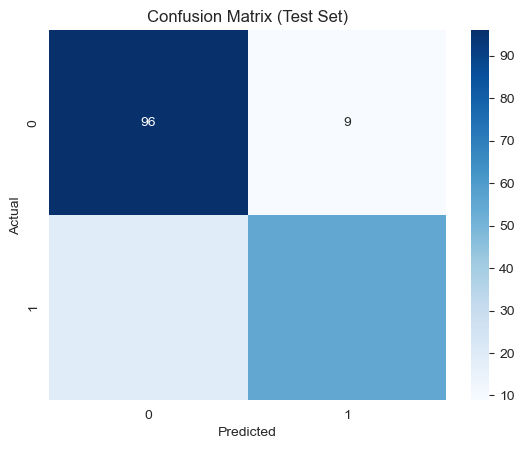

In [102]:
cm = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()